# 01 보스턴 집값 데이터

XGBOOST의 hyperparameter 목록은 다음과 같습니다.

https://xgboost.readthedocs.io/en/stable/parameter.html

보스턴 집값 데이터를 이용할 겁니다.

GridSearch로 가장 좋은 hyperparameter set을 찾아서 집값을 가장 잘 예측하는 xgboost 모델을 만들어봅시다.

이 때, hyperparameter는 최소 4종류를 이용해봅시다.

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('train.csv')
X = df[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']]
y = df['SalePrice']

rf2 = RandomForestClassifier()
kfold2 = KFold(n_splits=5)

param_grid = { "n_estimators" : [100, 150, 200, 250], "max_depth" : [None, 6, 9, 12], "min_samples_split" : [0.01, 0.05, 0.1], "max_features": ['auto', 'sqrt']}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
params = { 'n_estimators}': [100, 200], 'max_depth': [3, 5],'learning_rate': [0.05, 0.1],'subsample': [0.8, 1.0]}
grid_search = GridSearchCV(estimator = rf2, param_grid=param_grid, cv=kfold2)
grid_search.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklea

In [ ]:
grid_search.best_params_

# 02 Step function (activation function의 한 종류)
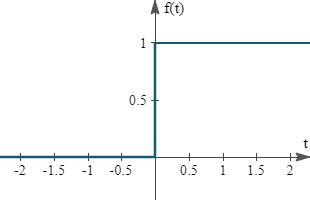

아래 슈도코드와 위 이미지의 도움을 받아서 step function 을 짜봅시다.

<pseudocode (자연어로 짜는 일종의 코드 도움말)>
- 음수가 들어오면 0 (False)
- 양수가 들어오면 1 (True)
- 그렇다면? 음수일 때 False를, 양수일 때 True를 return하게 한 다음에 integer로 바꾸면 이 함수가 만들어지지 않을까요?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(t):
    return np.array (t >= 0, dtype = int)

t = np.arange(-2, 2, 0.1)
y = step_function(t)

plt.plot(t,y)
plt.xlabel('t')
plt.ylabel = ('f(t)')
plt.title("Step Function")
plt.show()

# 03 Artificial Neural Network with numpy

`y = activation function (x*w+b)` 라는 식의 아주 작은 ANN이 하나 있다고 해봅시다.

- x : (2,)짜리 행렬 (값은 현윤이가 임의로 정해봅시다.)
- w : (2, 3) 짜리 행렬 (값은 현윤이가 임의로 정해봅시다.)
- b : (3,) 짜리 행렬 (값은 현윤이가 임의로 정해봅시다.)

- activation function : sigmoid, relu, step function 3가지 모두 해보면서 값이 달라지는 것을 관찰해봅시다.

In [ ]:
import numpy as np

x = np.array([1, 2])
w = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([1, 2, 3])

result = np.dot (x, w) + b
print ("x+w+b = ", result)

In [ ]:
# step functions
def step_function(t):
    return np.array (t >= 0, dtype=int)

# sigmoid
def sigmoid(t):
    return 1/(1+np.exp(-t))

# relu
def relu(t):
    return np.maximum(0, t)

#결과
print('step :', step_function(result))
print('sigmoid :', sigmoid(result))
print('relu :', relu(result))